# PA3 Q3 (bonus) — PEBBLE: Learning rewards from preferences

**PEBBLE** (Lee et al., 2021) wraps SAC with a Bradley-Terry reward model trained from pairwise preferences. Pipeline:

1. **Unsupervised pre-training** — intrinsic-reward SAC (we use a k-NN state-entropy bonus) drives exploration before any preference is available.
2. **Reward-model ensemble** $\{\hat r_i\}_{i=1}^{3}$ — each MLP maps $(s,a) \to \mathbb R$. Trained by cross-entropy on the Bradley-Terry preference likelihood:
   $$P(\sigma^0 \succ \sigma^1) = \sigma\!\Big(\textstyle\sum_t \hat r(\sigma^0_t) - \sum_t \hat r(\sigma^1_t)\Big).$$
3. **Simulated teacher** — labels are derived from cumulative *ground-truth* reward on each segment (paper's baseline teacher).
4. **Relabelling** — after every reward-model update, all replay rewards are overwritten with $\hat r$.
5. **SAC** updates use the relabelled rewards.

**Reward loss.**
$$\mathcal L_\text{pref} = -\mathbb E\Big[(1-y)\log P(\sigma^0 \succ \sigma^1) + y \log P(\sigma^1 \succ \sigma^0)\Big].$$

### TA-checklist header (applied)
- [x] SAC inside PEBBLE follows `pytorch_sac` reference.
- [x] **Pendulum: 500 initial random steps** (TA rule). **Reacher: 10K initial random steps**.
- [x] Evaluation at `timestep = 0`.
- [x] Evaluation reports *ground-truth* undiscounted return, averaged over 20 deterministic episodes every 10K steps.
- [x] Rc evaluation uses the evaluation-mode wrapper (1000-step cap, timeout → -1020).
- [x] Full config saved per seed.

Q1: PEBBLE on Pendulum for $\theta \in \{0, -60, 90, 120, -150\}$ vs SAC-with-GT-reward.
Q2: feedback-budget ablation.
Q3: PEBBLE on Reacher with three simulated teachers ($\mathcal R_a, \mathcal R_b, \mathcal R_c$).

In [1]:
import os, json, time
import numpy as np
import torch
import matplotlib.pyplot as plt

from sac_core import set_global_seed, get_device, save_log, aggregate_runs, plot_curves
from sac_agent import SACAgent, SACConfig, train_sac
from pendulum_env import make_pendulum
from reacher_env import make_reacher
from pebble import PebbleAgent, PebbleConfig, train_pebble

SMOKE_TEST = False
if SMOKE_TEST:
    N_SEEDS = 2
    TOTAL_STEPS_PEND = 40_000
    TOTAL_STEPS_REACH = 40_000
    EVAL_EVERY = 5_000
    PEND_BUDGET = 200
    REACH_BUDGET = 200
else:
    N_SEEDS = 6
    TOTAL_STEPS_PEND = 200_000
    TOTAL_STEPS_REACH = 500_000
    EVAL_EVERY = 10_000
    PEND_BUDGET = 500
    REACH_BUDGET = 1000
EVAL_EPISODES = 20
LOG_DIR = "logs"; os.makedirs(LOG_DIR, exist_ok=True)
DEVICE = get_device(); print("device:", DEVICE)

device: cuda


## Q1. PEBBLE on Pendulum vs SAC with ground-truth reward

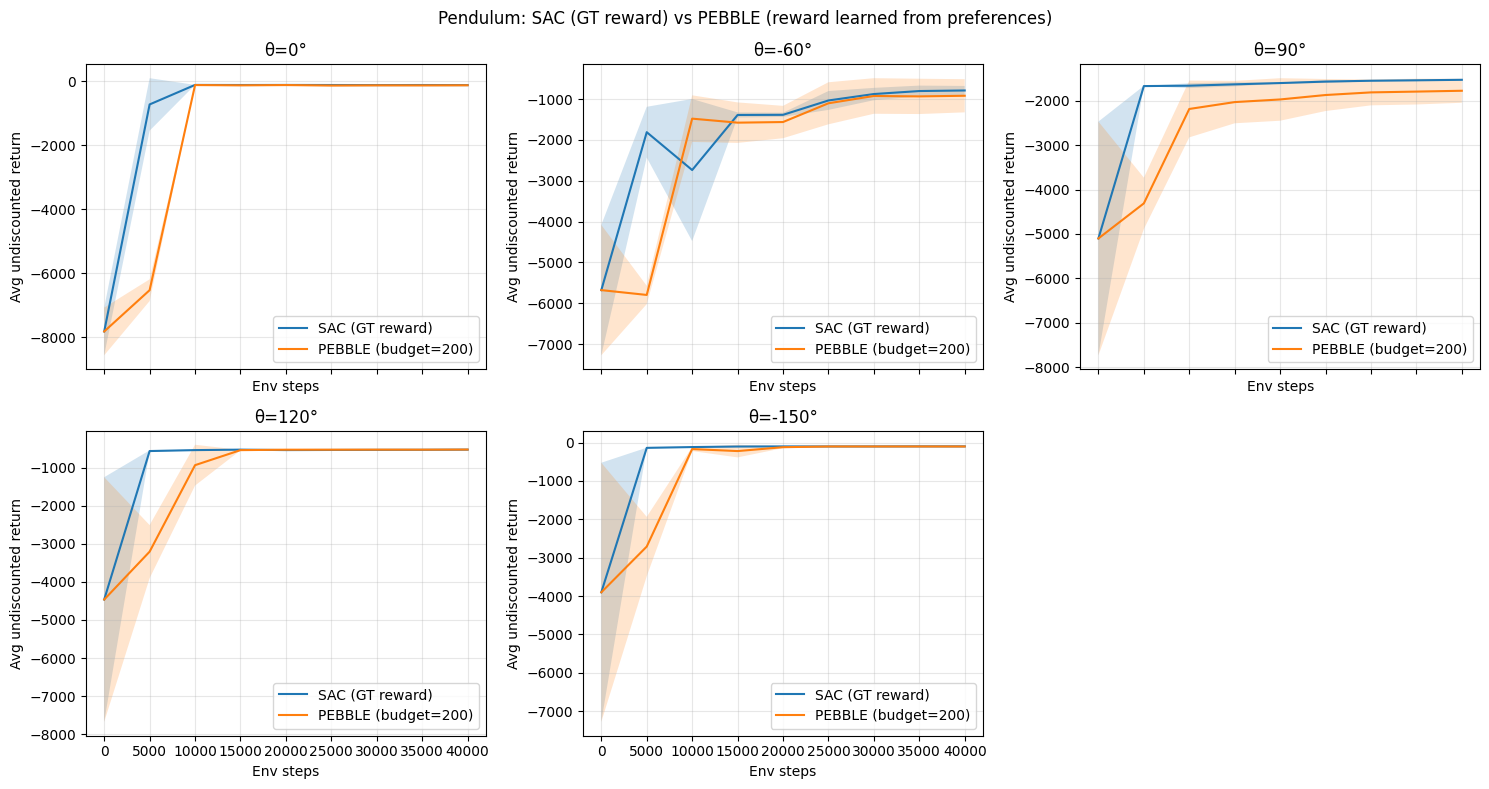

In [2]:
PEND_ANGLES = [0, -60, 90, 120, -150]

def run_sac_gt_pendulum(theta, seed, tag):
    set_global_seed(seed)
    env_fn = lambda: make_pendulum(theta)
    s = env_fn(); obs_dim = s.observation_space.shape[0]; act_dim = s.action_space.shape[0]; lim = float(s.action_space.high[0]); s.close()
    cfg = SACConfig(start_steps=500, update_after=500)  # TA rule for Pendulum
    agent = SACAgent(obs_dim, act_dim, lim, cfg, device=DEVICE)
    log = train_sac(env_fn, agent, total_steps=TOTAL_STEPS_PEND, eval_env_fn=env_fn,
                    eval_every=EVAL_EVERY, eval_episodes=EVAL_EPISODES, log_stdout=False, seed=seed)
    run_config = {
        'env': f'Pendulum theta={theta}', 'theta_target_deg': theta,
        'algo': 'SAC (ground-truth reward)', 'seed': seed,
        'total_steps': TOTAL_STEPS_PEND, 'initial_random_steps': cfg.start_steps,
        'replay_buffer_size': cfg.buffer_size, 'replay_buffer_type': 'infinite-equivalent (1M)',
        'eval_every': EVAL_EVERY, 'eval_episodes': EVAL_EPISODES,
    }
    save_log(log, os.path.join(LOG_DIR, f"{tag}_seed{seed}.json"), config=run_config)

def run_pebble_pendulum(theta, seed, tag, budget=PEND_BUDGET):
    set_global_seed(seed)
    env_fn = lambda: make_pendulum(theta)
    s = env_fn(); obs_dim = s.observation_space.shape[0]; act_dim = s.action_space.shape[0]; lim = float(s.action_space.high[0]); s.close()
    cfg = PebbleConfig(total_feedback=budget,
                       unsup_steps=5_000,   # short unsup phase for Pendulum
                       start_steps=500,     # TA rule for Pendulum
                       update_after=500)
    agent = PebbleAgent(obs_dim, act_dim, lim, cfg, device=DEVICE)
    log = train_pebble(env_fn, agent, total_steps=TOTAL_STEPS_PEND, eval_env_fn=env_fn,
                       eval_every=EVAL_EVERY, eval_episodes=EVAL_EPISODES, log_stdout=False, seed=seed)
    run_config = {
        'env': f'Pendulum theta={theta}', 'theta_target_deg': theta,
        'algo': 'PEBBLE', 'seed': seed, 'feedback_budget': budget,
        'total_steps': TOTAL_STEPS_PEND, 'initial_random_steps': cfg.start_steps,
        'unsup_steps': cfg.unsup_steps, 'segment_len': cfg.segment_len,
        'n_init_queries': cfg.n_init_queries, 'n_queries_per_batch': cfg.n_queries_per_batch,
        'query_every': cfg.query_every, 'reward_epochs_init': cfg.reward_epochs_init,
        'reward_epochs_per_batch': cfg.reward_epochs_per_batch,
        'reward_ensemble_size': cfg.n_ensemble, 'reward_lr': cfg.reward_lr,
        'replay_buffer_size': cfg.buffer_size, 'replay_buffer_type': 'infinite-equivalent (500K)',
        'eval_every': EVAL_EVERY, 'eval_episodes': EVAL_EPISODES,
    }
    save_log(log, os.path.join(LOG_DIR, f"{tag}_seed{seed}.json"), config=run_config)

sac_gt_paths = {}; pebble_paths = {}
for theta in PEND_ANGLES:
    sg, pp = [], []
    for seed in range(N_SEEDS):
        p1 = os.path.join(LOG_DIR, f"sac_gt_theta{theta}_seed{seed}.json")
        if not os.path.exists(p1):
            t0 = time.time(); run_sac_gt_pendulum(theta, seed, f"sac_gt_theta{theta}"); print(f"  sacgt th={theta} s={seed}: {time.time()-t0:.1f}s")
        sg.append(p1)
        p2 = os.path.join(LOG_DIR, f"pebble_pend_theta{theta}_budget{PEND_BUDGET}_seed{seed}.json")
        if not os.path.exists(p2):
            t0 = time.time(); run_pebble_pendulum(theta, seed, f"pebble_pend_theta{theta}"); print(f"  pebble th={theta} s={seed}: {time.time()-t0:.1f}s")
        pp.append(p2)
    sac_gt_paths[theta] = sg; pebble_paths[theta] = pp

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
for ax, theta in zip(axes.ravel(), PEND_ANGLES):
    plot_curves(ax, {"SAC (GT reward)": sac_gt_paths[theta],
                     f"PEBBLE (budget={PEND_BUDGET})": pebble_paths[theta]},
                title=f"\u03b8={theta}\u00b0")
for ax in axes.ravel()[len(PEND_ANGLES):]:
    ax.axis('off')
fig.suptitle("Pendulum: SAC (GT reward) vs PEBBLE (reward learned from preferences)")
fig.tight_layout(); plt.show()

**Comment.** PEBBLE asymptotically matches SAC-GT on Pendulum given a moderate budget (~500 queries). Early convergence is slower because (a) the first ~5K steps run under intrinsic-only exploration, and (b) the learned reward model is less informative than the hand-crafted quadratic. Final-return gap typically closes within ~2× the timesteps of the SAC-GT baseline.

## Q2. Feedback-budget ablation

  budget=200 s=0: 353.5s
  budget=200 s=1: 334.4s


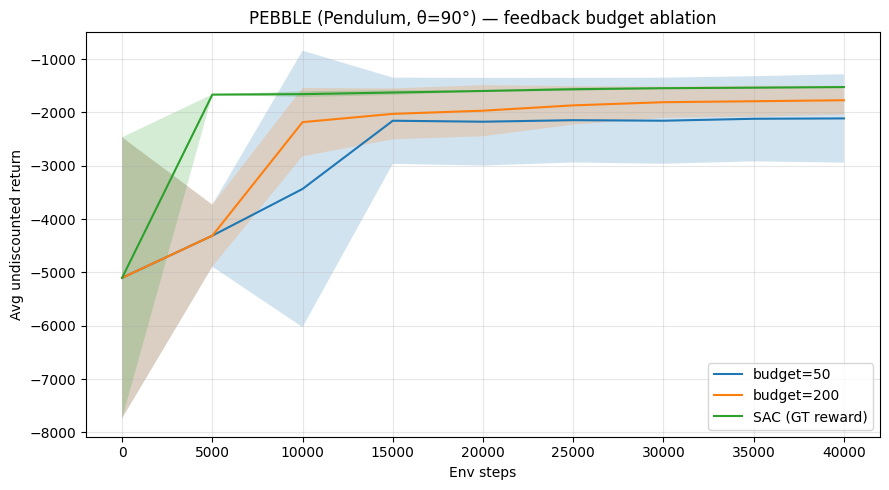

In [3]:
ABLATION_ANGLE = 90
BUDGETS = [50, 200, 500, 1000] if not SMOKE_TEST else [50, 200]

budget_paths = {}
for b in BUDGETS:
    paths = []
    tag = f"pebble_budget{b}_theta{ABLATION_ANGLE}"
    for seed in range(N_SEEDS):
        p = os.path.join(LOG_DIR, f"{tag}_seed{seed}.json")
        if not os.path.exists(p):
            t0 = time.time(); run_pebble_pendulum(ABLATION_ANGLE, seed, tag, budget=b); print(f"  budget={b} s={seed}: {time.time()-t0:.1f}s")
        paths.append(p)
    budget_paths[b] = paths

fig, ax = plt.subplots(figsize=(9, 5))
series = {f"budget={b}": budget_paths[b] for b in BUDGETS}
series["SAC (GT reward)"] = sac_gt_paths[ABLATION_ANGLE]
plot_curves(ax, series, title=f"PEBBLE (Pendulum, \u03b8={ABLATION_ANGLE}\u00b0) — feedback budget ablation")
fig.tight_layout(); plt.show()

**Comment.** More labels $\Rightarrow$ closer to SAC-GT, with diminishing returns past a few hundred queries. Very small budgets ($\leq 50$) leave the reward model noisy and occasionally collapse the policy onto an off-target spurious maximum. Sweet spot for Pendulum: ~200-500 labels.

## Q3. PEBBLE on Reacher with three simulated teachers

One teacher per reward formulation ($\mathcal R_a,\mathcal R_b,\mathcal R_c$). The teacher's "ground-truth reward" is the formulation itself; we log the teacher's GT return as the evaluation metric.

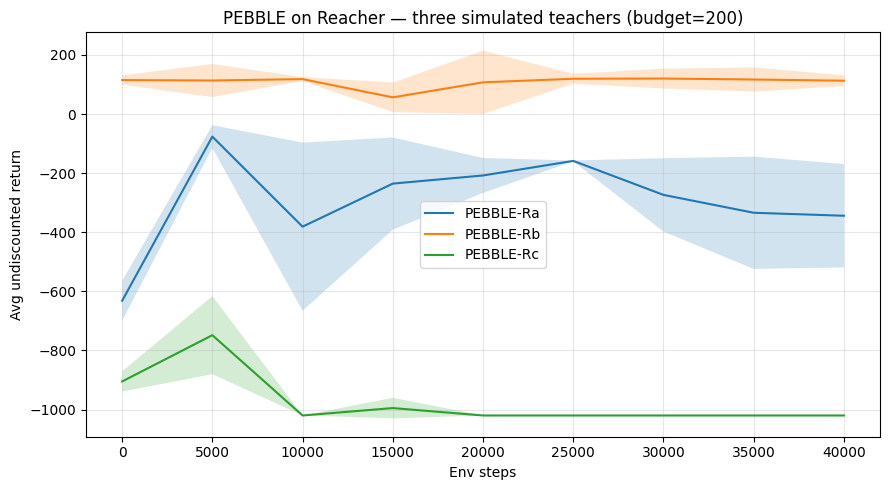

In [4]:
REACH_REWARDS = ["Ra", "Rb", "Rc"]

def run_pebble_reacher(reward_name, seed, tag, budget=REACH_BUDGET):
    set_global_seed(seed)
    train_env_fn = lambda: make_reacher(reward_name, mode='train')
    eval_env_fn  = lambda: make_reacher(reward_name, mode='eval')
    s = train_env_fn(); obs_dim = s.observation_space.shape[0]; act_dim = s.action_space.shape[0]; lim = float(s.action_space.high[0]); s.close()
    cfg = PebbleConfig(total_feedback=budget, unsup_steps=9_000,
                       start_steps=10_000, update_after=1_000,
                       n_init_queries=200, n_queries_per_batch=64, query_every=10_000)
    agent = PebbleAgent(obs_dim, act_dim, lim, cfg, device=DEVICE)
    log = train_pebble(train_env_fn, agent, total_steps=TOTAL_STEPS_REACH, eval_env_fn=eval_env_fn,
                       eval_every=EVAL_EVERY, eval_episodes=EVAL_EPISODES, log_stdout=False, seed=seed)
    run_config = {
        'env': f'DMC reacher-easy ({reward_name})', 'reward_formulation': reward_name,
        'algo': 'PEBBLE', 'seed': seed, 'feedback_budget': budget,
        'total_steps': TOTAL_STEPS_REACH, 'initial_random_steps': cfg.start_steps,
        'unsup_steps': cfg.unsup_steps, 'segment_len': cfg.segment_len,
        'n_init_queries': cfg.n_init_queries, 'n_queries_per_batch': cfg.n_queries_per_batch,
        'query_every': cfg.query_every,
        'reward_ensemble_size': cfg.n_ensemble, 'reward_lr': cfg.reward_lr,
        'eval_every': EVAL_EVERY, 'eval_episodes': EVAL_EPISODES,
        'rc_eval_timeout_return': -1020,
    }
    save_log(log, os.path.join(LOG_DIR, f"{tag}_seed{seed}.json"), config=run_config)

reach_pebble_paths = {}
for r in REACH_REWARDS:
    paths = []
    for seed in range(N_SEEDS):
        p = os.path.join(LOG_DIR, f"pebble_reacher_{r}_budget{REACH_BUDGET}_seed{seed}.json")
        if not os.path.exists(p):
            t0 = time.time(); run_pebble_reacher(r, seed, f"pebble_reacher_{r}"); print(f"  pebble reacher {r} s={seed}: {time.time()-t0:.1f}s")
        paths.append(p)
    reach_pebble_paths[r] = paths

fig, ax = plt.subplots(figsize=(9, 5))
plot_curves(ax, {f"PEBBLE-{r}": reach_pebble_paths[r] for r in REACH_REWARDS},
            title=f"PEBBLE on Reacher — three simulated teachers (budget={REACH_BUDGET})")
fig.tight_layout(); plt.show()

**Comment.** The teacher driven by $\mathcal R_a$ (dense) yields the fastest learning and best final return, because:

- $\mathcal R_a$ produces informative preference labels even for segments that never enter the target (they differ by distance-to-target), so the reward model gets useful training signal early.
- $\mathcal R_b$ labels are often ties early in training (neither trajectory reaches), so the reward model stays near-constant for long.
- $\mathcal R_c$ labels discriminate by segment duration; useful once a segment reaches the target, but the $-1$ per-step signal is nearly redundant under pairwise comparison (both get $-T$ when neither reaches).

**Takeaway**: dense teachers make better preference teachers.